# Greedy Knapsack Problem (Fractional)
In this lab, we explore the Fractional Knapsack Problem, a fundamental optimization problem that demonstrates the Greedy Algorithmic Paradigm.
We will implement it using greedy selection (based on value-to-weight ratio) and analyze its time and space complexity.

- Created by Dr. Ajay

# Problem Definition
Given a set of
n
n items, each with:
Value vi
Weight wi
A knapsack with maximum capacity **W**

Goal: maximize total value that can be put in the knapsack.
Constraint: You may take fractions of items.

Greedy Strategy:

*  Sort items by decreasing ratio vi/wi
*  Select items fully until knapsack is full.
*  Take fraction of the next item if capacity remains.

In [ ]:
def fractional_knapsack(values, weights, capacity):
    n = len(values)
    ratios = [(values[i] / weights[i], values[i], weights[i]) for i in range(n)]
    ratios.sort(key=lambda x: x[0], reverse=True)
    total_value = 0.0
    remaining_capacity = capacity
    for ratio, value, weight in ratios:
        if remaining_capacity == 0:
            break
        if weight <= remaining_capacity:
            total_value += value
            remaining_capacity -= weight
        else:
            fraction = remaining_capacity / weight
            total_value += value * fraction
            remaining_capacity = 0
    return total_value

values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50
print(fractional_knapsack(values, weights, capacity))


240.0


In this lab, we implement Huffman Coding, a greedy algorithm used for lossless data compression.
It assigns variable-length binary codes to input symbols based on their frequencies, ensuring that more frequent symbols receive shorter codes and less frequent symbols receive longer codes.

This algorithm constructs a binary tree (Huffman Tree) where each leaf node represents a character, and the path from the root to a leaf gives the character’s binary code.

Use:
Huffman Tree Construction using a Min-Priority Queue (Min-Heap).
Code generation for each character.
Encoding and decoding using the generated Huffman codes.
Complexity analysis and comparison with fixed-length encoding.

# Pseudocode:
1. Create a leaf node for each character and insert all nodes into a
2. min-heap by frequency.
   *  While the heap has more than one node:
   * Extract two nodes with the lowest frequencies.
   * Create a new internal node with frequency = sum of the two.
   *  Set the two extracted nodes as left and right children.
   *  Insert the new node back into the min-heap.
3. The remaining node is the root of the Huffman Tree.

4. Traverse the tree:
   * Assign 0 for left edge and 1 for right edge.
   * The resulting paths from root to leaves give Huffman codes.

Huffman Codes: {'a': '000', 'h': '001', 'l': '0100', 'd': '0101', 'n': '011', 'm': '1000', 'o': '1001', 'i': '1010', 't': '10110', 'r': '10111', ' ': '1100', 'f': '1101', 'g': '1110', 'u': '11110', 'c': '11111'}
Original: huffman coding algorithm
Encoded: 0011111011011101100000001111001111110010101101001111101100000010011101001101111010101100011000
Decoded: huffman coding algorithm
Fixed-length encoding size: 192 bits
Huffman encoding size: 94 bits


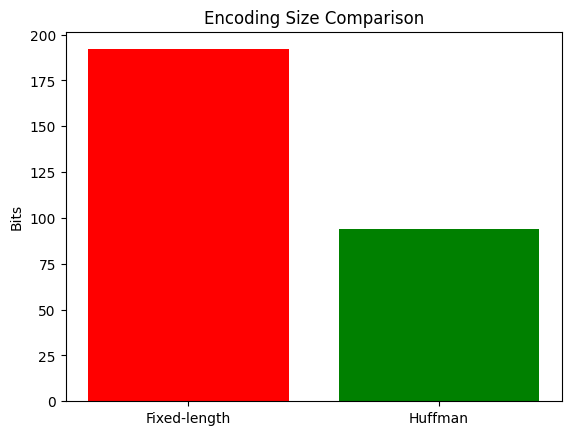

In [ ]:
import heapq
import matplotlib.pyplot as plt

class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None


    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(freqs):
    heap = [Node(char, freq) for char, freq in freqs.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

def generate_codes(node, prefix="", code_map={}):
    if node is None:
        return
    if node.char is not None:
        code_map[node.char] = prefix
    generate_codes(node.left, prefix + "0", code_map)
    generate_codes(node.right, prefix + "1", code_map)
    return code_map

def encode(text, code_map):
    return "".join(code_map[ch] for ch in text)

def decode(encoded_text, root):
    decoded = []
    node = root
    for bit in encoded_text:
        node = node.left if bit == "0" else node.right
        if node.char is not None:
            decoded.append(node.char)
            node = root
    return "".join(decoded)


text = "huffman coding algorithm"
freqs = {}
for ch in text:
    freqs[ch] = freqs.get(ch, 0) + 1

root = build_huffman_tree(freqs)
codes = generate_codes(root)

print("Huffman Codes:", codes)

encoded = encode(text, codes)
decoded = decode(encoded, root)

print("Original:", text)
print("Encoded:", encoded)
print("Decoded:", decoded)

fixed_length_bits = len(text) * 8
huffman_bits = len(encoded)

print("Fixed-length encoding size:", fixed_length_bits, "bits")
print("Huffman encoding size:", huffman_bits, "bits")

labels = ["Fixed-length", "Huffman"]
sizes = [fixed_length_bits, huffman_bits]

plt.bar(labels, sizes, color=['red', 'green'])
plt.title("Encoding Size Comparison")
plt.ylabel("Bits")
plt.show()
